# Análise da Rede Amazon0302
**Grafo dirigido (Digraph) usando a biblioteca algs4**

Instale as dependências antes de rodar:
```
pip install algs4 powerlaw matplotlib numpy
```

## 1. Imports e Parâmetros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import powerlaw

# ---- algs4 ----
from algs4.digraph import Digraph   # grafo DIRIGIDO

# ======== AJUSTE O CAMINHO AQUI ========
ARQUIVO_TXT = r"/home/joaoviitosx/Documentos/Faculdade/Grafos/amazon0302.txt/Amazon0302.txt"
# =======================================

# ======== PARÂMETROS DO "TRECHO RETO" ========
MIN_PTS_JANELA = 10
JANELA_MAX     = 30
N_BINS_LOG     = 25
# ============================================

# Safety check — prints all method names so you can confirm outdegree/indegree exist
_g_test = Digraph(2)
_g_test.add_edge(0, 1)
print("Digraph methods:", [m for m in dir(_g_test) if not m.startswith('_')])
print("Imports OK")

Digraph methods: ['E', 'V', 'add_edge', 'adj', 'degree', 'max_degree', 'number_of_self_loops', 'reverse']
Imports OK


## 2. Funções Auxiliares

In [ ]:
def r2_linear(x, y):
    a, b = np.polyfit(x, y, 1)
    y_hat  = a * x + b
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else -np.inf


def log_binning(k_vals, pk, nbins=25):
    k_vals = np.asarray(k_vals, dtype=float)
    pk     = np.asarray(pk,     dtype=float)
    mask   = (k_vals > 0) & (pk > 0)
    k_vals, pk = k_vals[mask], pk[mask]
    kmin, kmax = k_vals.min(), k_vals.max()
    if kmin <= 0 or kmax <= 0 or kmin == kmax:
        return k_vals, pk
    bins = np.logspace(np.log10(kmin), np.log10(kmax), nbins + 1)
    k_b, p_b = [], []
    for i in range(nbins):
        m = (k_vals >= bins[i]) & (k_vals < bins[i + 1])
        if np.any(m):
            k_mean = np.exp(np.mean(np.log(k_vals[m])))
            p_mean = np.mean(pk[m])
            if p_mean > 0:
                k_b.append(k_mean)
                p_b.append(p_mean)
    return np.array(k_b), np.array(p_b)


def reta(k_b, p_b, xmin, min_pts=10, janela_max=30):
    mask = k_b >= xmin
    k    = k_b[mask]
    p    = p_b[mask]
    mask2 = (k > 0) & (p > 0)
    k, p  = k[mask2], p[mask2]
    n = len(k)
    x = np.log10(k)
    y = np.log10(p)
    if n < min_pts:
        a, b = np.polyfit(x, y, 1)
        return k.min(), k.max(), a, b, r2_linear(x, y)
    best = None
    for i in range(0, n - min_pts + 1):
        for j in range(i + min_pts, min(n, i + janela_max) + 1):
            xw, yw = x[i:j], y[i:j]
            if (yw.max() - yw.min()) < 0.15:
                continue
            r2 = r2_linear(xw, yw)
            if not np.isfinite(r2):
                continue
            a, b = np.polyfit(xw, yw, 1)
            if a >= 0:
                continue
            if best is None or r2 > best[0]:
                best = (r2, i, j, a, b)
    if best is None:
        i, j = 0, min_pts
        a, b = np.polyfit(x[i:j], y[i:j], 1)
        return k[i], k[j - 1], a, b, r2_linear(x[i:j], y[i:j])
    _, i, j, a, b = best
    return k[i], k[j - 1], a, b, r2_linear(x[i:j], y[i:j])


print("Funções definidas OK")

Funções definidas OK


## 3. Leitura do Arquivo e Construção do Dígrafo (algs4)

O Amazon0302 é um **grafo dirigido**: a aresta `u → v` significa
*"quem comprou u também comprou v"*, que não é o mesmo que `v → u`.
Por isso usamos `Digraph` (e não `Graph`), que preserva a direção de cada aresta
e permite consultar `indegree` e `outdegree` separadamente.

In [5]:
print("Lendo arestas...")

raw_edges = []
node_set  = set()

ARQUIVO_TXT = "/home/joaoviitosx/Documentos/Faculdade/Grafos/amazon0302.txt/Amazon0302.txt"

with open(ARQUIVO_TXT, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#") or line.startswith("%"):
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        u, v = int(parts[0]), int(parts[1])
        raw_edges.append((u, v))
        node_set.add(u)
        node_set.add(v)

# algs4 Digraph precisa do número de vértices logo na criação.
# Amazon0302 usa IDs 0..262110, então V = maior ID + 1.
V = max(node_set) + 1
print(f"Construindo Digraph com {V} vértices e {len(raw_edges)} arestas...")

G = Digraph(V)            # <-- algs4: cria dígrafo com V vértices
for u, v in raw_edges:
    G.add_edge(u, v)      # <-- algs4: insere aresta dirigida u → v

print(f"Dígrafo construído: V={G.V}  E={G.E}")

Lendo arestas...
Construindo Digraph com 262111 vértices e 1234877 arestas...
Dígrafo construído: V=262111  E=1234877


## 4. Graus e Estatísticas

In [ ]:
# G.adj[v] só guarda arestas de SAÍDA (out-degree).
# Para grau total precisamos também do in-degree.
# algs4 fornece G.reverse() — dígrafo com todas as arestas invertidas —
# então G.reverse().adj[v].size() == in-degree de v no grafo original.
G_rev = G.reverse()
graus = np.array(
    [G.adj[v].size() + G_rev.adj[v].size() for v in range(G.V)],
    dtype=int
)

print("===== ESTATÍSTICAS DA REDE =====")
print(f"Número de nós:     {G.V}")
print(f"Número de arestas: {G.E}")
print(f"Grau médio:        {graus.mean():.4f}")
print(f"Grau máximo:       {graus.max()}")

===== ESTATÍSTICAS DA REDE =====
Número de nós:     262111
Número de arestas: 1234877
Grau médio:        9.4225
Grau máximo:       425


## 5. Distribuição de Graus e Ajuste Power-Law

In [ ]:
k_vals, counts = np.unique(graus[graus > 0], return_counts=True)
pk = counts / len(graus)

fit  = powerlaw.Fit(graus[graus > 0], discrete=True, verbose=False)
xmin = fit.power_law.xmin
print(f"xmin estimado (powerlaw): {xmin}")

k_b, p_b = log_binning(k_vals, pk, nbins=N_BINS_LOG)

k_ini, k_fim, slope, intercept, r2 = reta(
    k_b, p_b, xmin,
    min_pts=MIN_PTS_JANELA,
    janela_max=JANELA_MAX
)
gamma_reg = -slope

print("\n===== TRECHO LINEAR IDENTIFICADO =====")
print(f"Intervalo:       {k_ini:.2f} ≤ k ≤ {k_fim:.2f}")
print(f"Slope (log-log): {slope:.4f}")
print(f"γ (expoente):    {gamma_reg:.4f}")
print(f"R² no trecho:    {r2:.4f}")

xmin estimado (powerlaw): 6.0

===== TRECHO LINEAR IDENTIFICADO =====
Intervalo:       9.97 ≤ k ≤ 88.79
Slope (log-log): -4.1015
γ (expoente):    4.1015
R² no trecho:    0.9980


/var/data/python/lib/python3.13/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


## 6. Histograma de Frequência (escala linear)

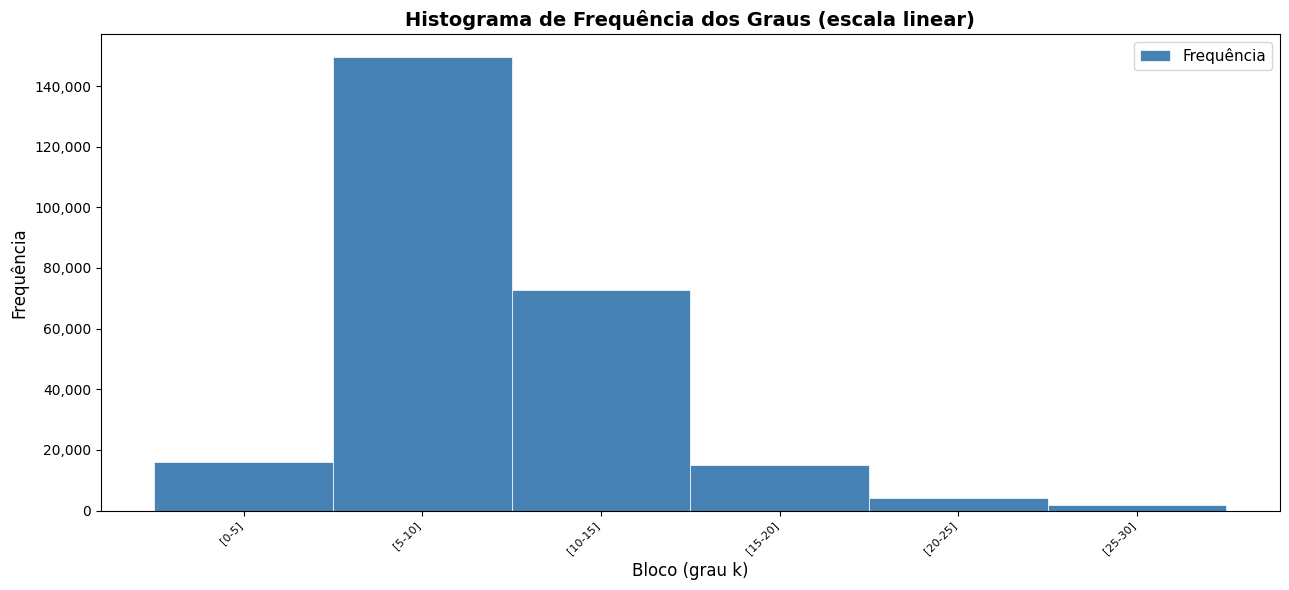

Figura salva: histograma_frequencia_graus.png


In [10]:
BIN_SIZE   = 5
k_max_plot = int(np.percentile(graus, 99))
bins       = np.arange(0, k_max_plot + BIN_SIZE, BIN_SIZE)

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(
    graus, bins=bins,
    color='steelblue', edgecolor='white', linewidth=0.5, label='Frequência'
)
edges = bins
tick_positions = (edges[:-1] + edges[1:]) / 2
tick_labels    = [f'[{int(edges[i])}-{int(edges[i+1])}]' for i in range(len(edges)-1)]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Bloco (grau k)', fontsize=12)
ax.set_ylabel('Frequência', fontsize=12)
ax.set_title('Histograma de Frequência dos Graus (escala linear)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('histograma_frequencia_graus.png', dpi=300)
plt.show()
print('Figura salva: histograma_frequencia_graus.png')

## 7. Distribuição P(k) em Escala Log-Log (com trecho linear)

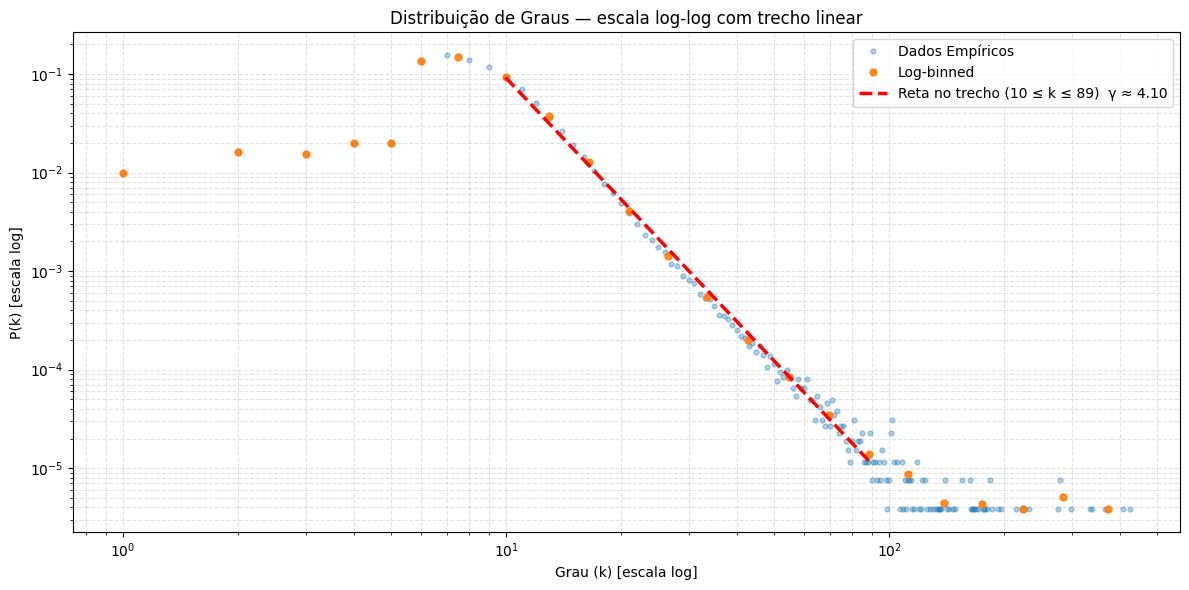

Figura salva: histograma_graus_cauda_ajustada.png


In [11]:
k_fit  = np.logspace(np.log10(k_ini), np.log10(k_fim), 150)
pk_fit = 10 ** (slope * np.log10(k_fit) + intercept)

plt.figure(figsize=(12, 6))
plt.loglog(k_vals, pk,    'o', markersize=3.5, label="Dados Empíricos", alpha=0.35)
plt.loglog(k_b,    p_b,   'o', markersize=5,   label="Log-binned",      alpha=0.9)
plt.loglog(
    k_fit, pk_fit, '--', color='red', linewidth=2.5,
    label=f"Reta no trecho ({k_ini:.0f} ≤ k ≤ {k_fim:.0f})  γ ≈ {gamma_reg:.2f}"
)
plt.xlabel("Grau (k) [escala log]")
plt.ylabel("P(k) [escala log]")
plt.title("Distribuição de Graus — escala log-log com trecho linear")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("histograma_graus_cauda_ajustada.png", dpi=300)
plt.show()
print("Figura salva: histograma_graus_cauda_ajustada.png")

## 8. Distribuição P(k) em Escala Linear

O mesmo gráfico anterior, mas **sem** transformação logarítmica nos eixos.
Aqui fica evidente a forma de cauda pesada: a grande maioria dos nós tem grau
baixo e pouquíssimos nós têm grau muito alto — o que torna a power-law quase
invisível nesta escala, justificando por que usamos o log-log para analisá-la.

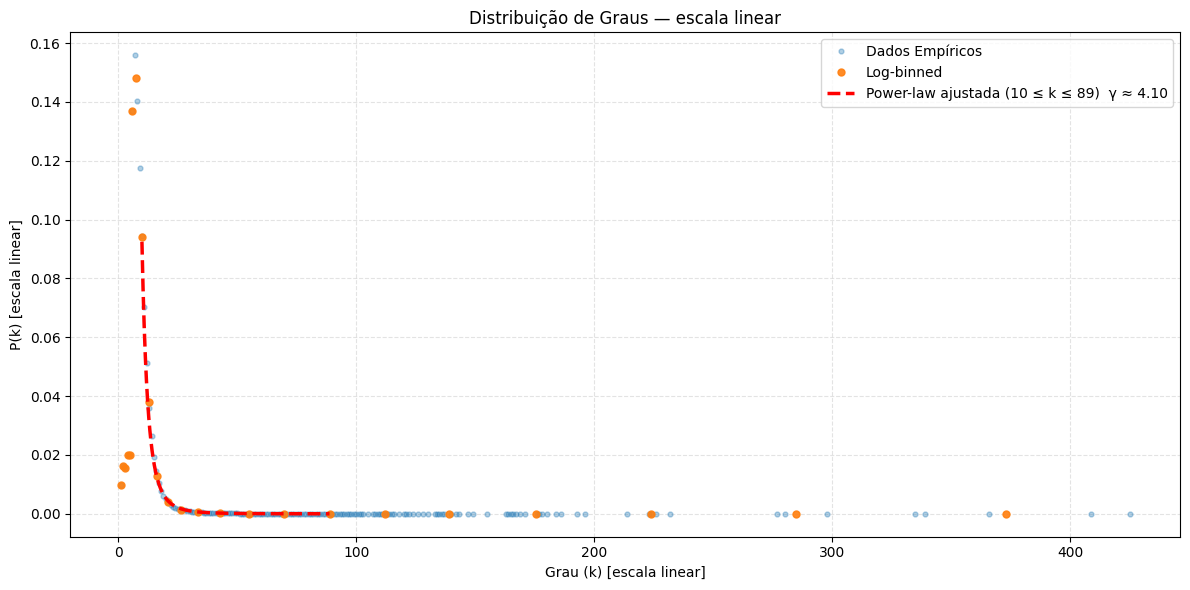

Figura salva: histograma_graus_escala_linear.png


In [12]:
# Curva power-law ajustada convertida de volta para escala linear
k_fit_lin  = np.linspace(k_ini, k_fim, 500)
pk_fit_lin = 10 ** (slope * np.log10(k_fit_lin) + intercept)

plt.figure(figsize=(12, 6))
plt.plot(k_vals, pk,    'o', markersize=3.5, label="Dados Empíricos", alpha=0.35)
plt.plot(k_b,    p_b,   'o', markersize=5,   label="Log-binned",      alpha=0.9)
plt.plot(
    k_fit_lin, pk_fit_lin, '--', color='red', linewidth=2.5,
    label=f"Power-law ajustada ({k_ini:.0f} ≤ k ≤ {k_fim:.0f})  γ ≈ {gamma_reg:.2f}"
)
plt.xlabel("Grau (k) [escala linear]")
plt.ylabel("P(k) [escala linear]")
plt.title("Distribuição de Graus — escala linear")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("histograma_graus_escala_linear.png", dpi=300)
plt.show()
print("Figura salva: histograma_graus_escala_linear.png")

## 9. Exportar CSV

In [ ]:
np.savetxt(
    "histograma_graus_normalizado.csv",
    np.column_stack([k_vals, pk]),
    delimiter=",", header="k,P(k)", comments=""
)
print("CSV salvo: histograma_graus_normalizado.csv")